<a href="https://colab.research.google.com/github/firuztahsinrodshi/traveliq-ota-business-intelligence/blob/main/notebooks/02_eda_customer_hotel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# TravelIQ OTA — Notebook 2: Exploratory Data Analysis
# Author: Firuz Tahsin Rodshi
# ============================================================

# Cell 1 — Setup
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0a0a0a'
plt.rcParams['axes.facecolor'] = '#141414'
plt.rcParams['axes.edgecolor'] = '#2a2a2a'
plt.rcParams['text.color'] = '#e7efe9'
plt.rcParams['axes.labelcolor'] = '#e7efe9'
plt.rcParams['xtick.color'] = '#84938a'
plt.rcParams['ytick.color'] = '#84938a'
plt.rcParams['grid.color'] = '#1f261f'
plt.rcParams['grid.alpha'] = 0.5

GREEN  = '#34d399'
BLUE   = '#60a5fa'
PURPLE = '#7c6bff'
YELLOW = '#fbbf24'
RED    = '#f87171'
TEAL   = '#2dd4bf'
COLORS = [GREEN, BLUE, PURPLE, YELLOW, RED, TEAL, '#f472b6', '#a78bfa']

print("Setup complete")

Setup complete


In [2]:
# Cell 2 — Connect and load core tables
from google.colab import files
print("Upload traveliq.db")
files.upload()

conn = sqlite3.connect('traveliq.db')

bookings  = pd.read_sql("SELECT * FROM fact_bookings",  conn)
reviews   = pd.read_sql("SELECT * FROM fact_reviews",   conn)
marketing = pd.read_sql("SELECT * FROM fact_marketing", conn)
funnel    = pd.read_sql("SELECT * FROM fact_funnel",    conn)

# ── Check what columns actually exist ──────────────────────────
print("Bookings columns:")
print(bookings.columns.tolist())
print(f"\nBookings shape: {bookings.shape}")
print(f"Reviews shape:  {reviews.shape}")

Upload traveliq.db


Saving traveliq.db to traveliq.db
Bookings columns:
['hotel_id', 'customer_id', 'room_id', 'arrival_date_id', 'lead_time', 'nights_weekend', 'nights_weekday', 'total_nights', 'adults', 'children', 'babies', 'total_guests', 'meal_plan', 'market_segment', 'distribution_channel', 'is_cancelled', 'adr', 'total_revenue', 'required_parking', 'special_requests', 'reservation_status', 'deposit_type']

Bookings shape: (117587, 22)
Reviews shape:  (515738, 11)


In [4]:
# Cell 2 — Connect and load core tables (auto-detect filename)
import glob
import os

# Find whatever .db file Colab saved — handles traveliq.db, traveliq (1).db, etc.
db_files = glob.glob('traveliq*.db')
if not db_files:
    raise FileNotFoundError("No traveliq .db file found. Please upload it first.")

db_path = sorted(db_files)[-1]  # takes the most recent one
print(f"Connecting to: {db_path}")

conn = sqlite3.connect(db_path)

# Verify tables exist
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    conn
)
print(f"Tables found: {tables['name'].tolist()}")

bookings  = pd.read_sql("SELECT * FROM fact_bookings",  conn)
reviews   = pd.read_sql("SELECT * FROM fact_reviews",   conn)
marketing = pd.read_sql("SELECT * FROM fact_marketing", conn)
funnel    = pd.read_sql("SELECT * FROM fact_funnel",    conn)

# Reconstruct arrival_date from arrival_date_id
base_date = pd.Timestamp('2015-01-01')
bookings['arrival_date'] = pd.to_datetime(
    bookings['arrival_date_id'].apply(
        lambda x: base_date + pd.Timedelta(days=int(x))
        if pd.notnull(x) and x >= 0 else pd.NaT
    )
)

# Derived columns
bookings['arrival_month']      = bookings['arrival_date'].dt.month
bookings['arrival_month_name'] = bookings['arrival_date'].dt.strftime('%b')
bookings['arrival_year']       = bookings['arrival_date'].dt.year
bookings['arrival_period']     = bookings['arrival_date'].dt.to_period('M').astype(str)
bookings['hotel_type']         = bookings['hotel_id'].map(
    {1: 'Resort Hotel', 2: 'City Hotel'}
)

completed = bookings[bookings['is_cancelled'] == 0].copy()

print("\n" + "=" * 55)
print("TRAVELIQ DATABASE LOADED")
print("=" * 55)
print(f"  Bookings:          {len(bookings):>10,} rows")
print(f"  Reviews:           {len(reviews):>10,} rows")
print(f"  Marketing:         {len(marketing):>10,} rows")
print(f"  Funnel:            {len(funnel):>10,} rows")
print(f"\n  Cancellation rate: {bookings['is_cancelled'].mean()*100:.1f}%")
print(f"  Avg ADR:           ${completed['adr'].mean():.2f}")
print(f"  Avg stay length:   {completed['total_nights'].mean():.1f} nights")
print(f"  Total revenue:     ${completed['total_revenue'].sum():,.0f}")
print(f"  Date range:        {bookings['arrival_date'].min().date()} → {bookings['arrival_date'].max().date()}")

Connecting to: traveliq.db
Tables found: ['dim_country', 'dim_customer', 'dim_date', 'dim_device', 'dim_hotel', 'dim_room', 'fact_bookings', 'fact_funnel', 'fact_marketing', 'fact_payments', 'fact_reviews', 'sqlite_sequence']

TRAVELIQ DATABASE LOADED
  Bookings:             117,587 rows
  Reviews:              515,738 rows
  Marketing:                150 rows
  Funnel:                   450 rows

  Cancellation rate: 37.6%
  Avg ADR:           $102.38
  Avg stay length:   3.4 nights
  Total revenue:     $25,986,976
  Date range:        2015-07-01 → 2017-08-31


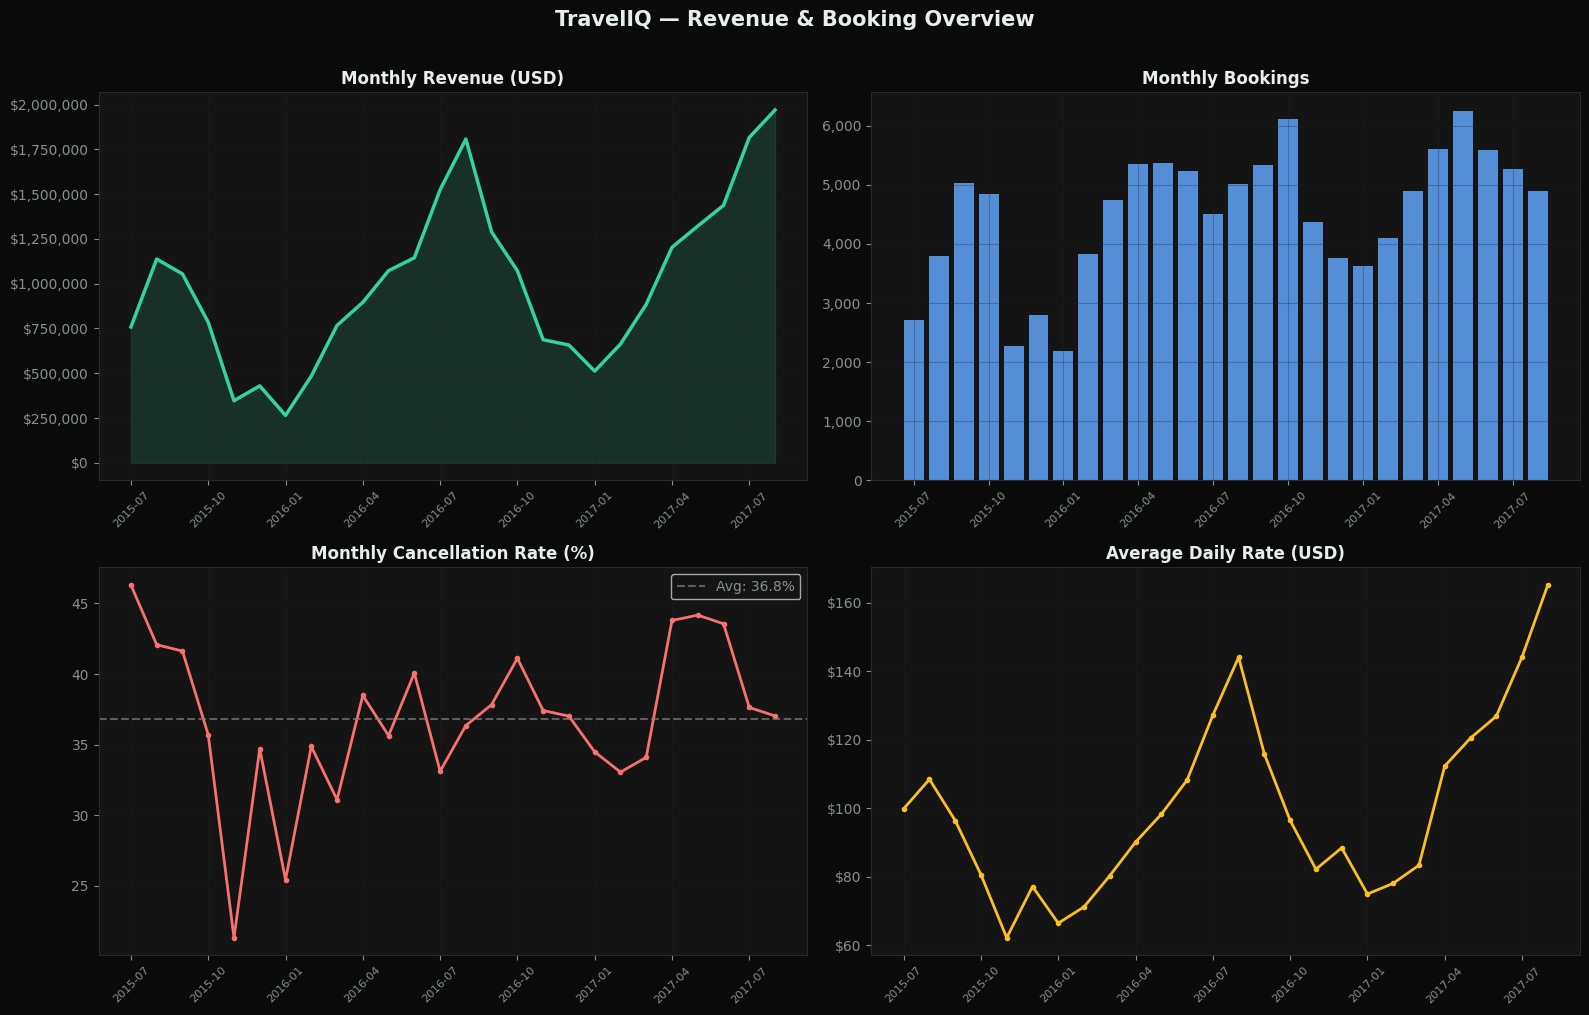

REVENUE FINDINGS:
  Peak month:      2017-08 — $1,970,182
  Lowest month:    2016-01 — $264,521
  Avg cancel rate: 36.8%
  Total revenue:   $25,986,976


In [6]:
# Cell 3 — Revenue & Booking Trends
monthly_agg = bookings.groupby('arrival_period').agg(
    bookings=('hotel_id','count'),          # hotel_id exists in every row
    revenue=('total_revenue','sum'),
    cancel_rate=('is_cancelled','mean'),
    avg_adr=('adr','mean')
).reset_index()
monthly_agg = monthly_agg.rename(columns={'arrival_period':'month'})
monthly_agg['cancel_rate'] = monthly_agg['cancel_rate'] * 100
monthly_agg = monthly_agg.sort_values('month').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('TravelIQ — Revenue & Booking Overview', fontsize=15,
             fontweight='bold', color='#e7efe9', y=1.01)

# Revenue
ax = axes[0,0]
ax.plot(range(len(monthly_agg)), monthly_agg['revenue'],
        color=GREEN, linewidth=2.5)
ax.fill_between(range(len(monthly_agg)), monthly_agg['revenue'],
                alpha=0.15, color=GREEN)
ax.set_title('Monthly Revenue (USD)', color='#e7efe9', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_xticks(range(0, len(monthly_agg), 3))
ax.set_xticklabels(monthly_agg['month'].iloc[::3], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3)

# Bookings
ax = axes[0,1]
ax.bar(range(len(monthly_agg)), monthly_agg['bookings'],
       color=BLUE, alpha=0.85)
ax.set_title('Monthly Bookings', color='#e7efe9', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_xticks(range(0, len(monthly_agg), 3))
ax.set_xticklabels(monthly_agg['month'].iloc[::3], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3)

# Cancellation rate
ax = axes[1,0]
ax.plot(range(len(monthly_agg)), monthly_agg['cancel_rate'],
        color=RED, linewidth=2, marker='o', markersize=3)
avg_cancel = monthly_agg['cancel_rate'].mean()
ax.axhline(y=avg_cancel, color='gray', linestyle='--', alpha=0.7,
           label=f'Avg: {avg_cancel:.1f}%')
ax.set_title('Monthly Cancellation Rate (%)', color='#e7efe9', fontweight='bold')
ax.legend(facecolor='#141414', labelcolor='#84938a')
ax.set_xticks(range(0, len(monthly_agg), 3))
ax.set_xticklabels(monthly_agg['month'].iloc[::3], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3)

# ADR
ax = axes[1,1]
ax.plot(range(len(monthly_agg)), monthly_agg['avg_adr'],
        color=YELLOW, linewidth=2, marker='o', markersize=3)
ax.set_title('Average Daily Rate (USD)', color='#e7efe9', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))
ax.set_xticks(range(0, len(monthly_agg), 3))
ax.set_xticklabels(monthly_agg['month'].iloc[::3], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_revenue_trends.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0a')
plt.show()

peak_month = monthly_agg.loc[monthly_agg['revenue'].idxmax(), 'month']
peak_rev   = monthly_agg['revenue'].max()
low_month  = monthly_agg.loc[monthly_agg['revenue'].idxmin(), 'month']
low_rev    = monthly_agg['revenue'].min()

print("REVENUE FINDINGS:")
print(f"  Peak month:      {peak_month} — ${peak_rev:,.0f}")
print(f"  Lowest month:    {low_month} — ${low_rev:,.0f}")
print(f"  Avg cancel rate: {avg_cancel:.1f}%")
print(f"  Total revenue:   ${monthly_agg['revenue'].sum():,.0f}")

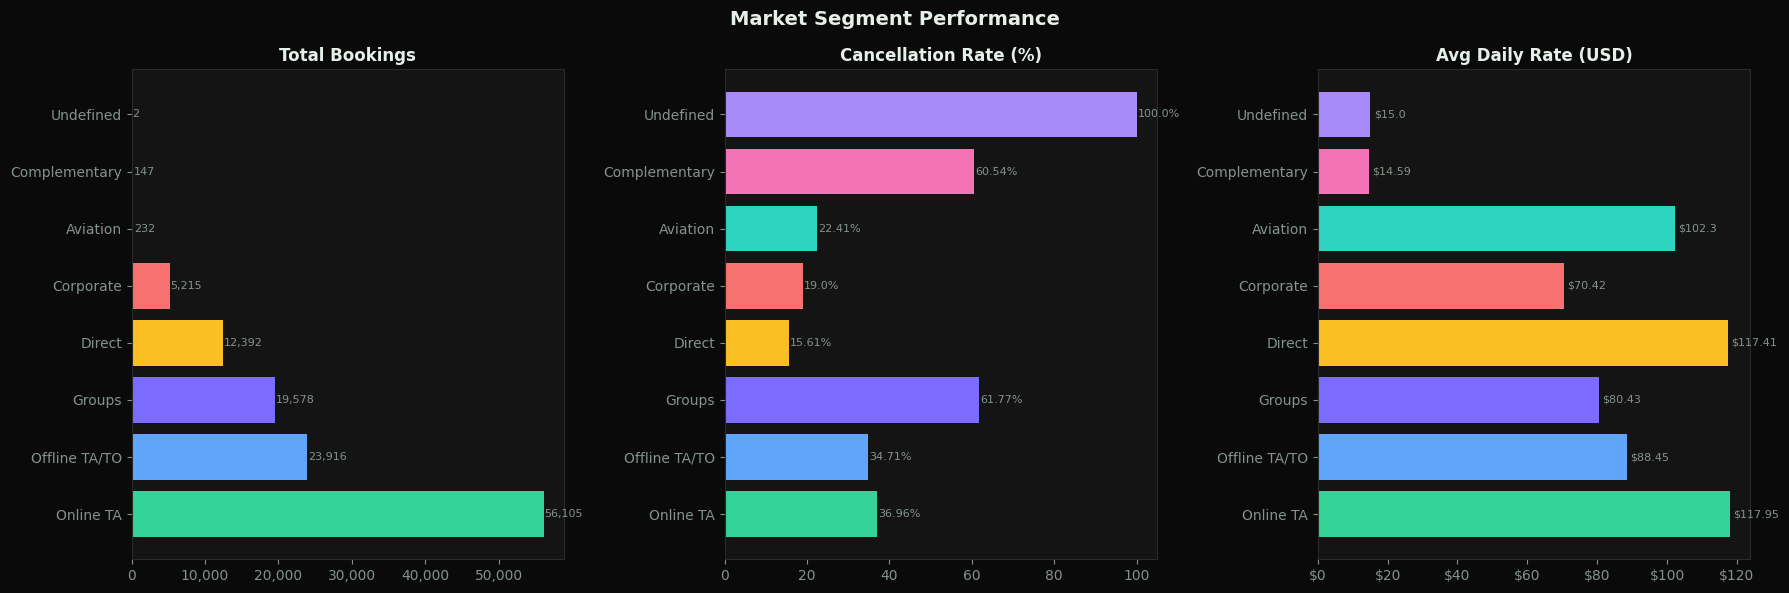

SEGMENT FINDINGS:
  Lowest cancel rate:  Direct (15.61%)
  Highest cancel rate: Undefined (100.0%)
  Highest ADR:         Online TA ($117.95)

Full segment table:
market_segment  bookings  cancel_rate  avg_adr  avg_nights
     Online TA     56105        36.96   117.95         3.6
 Offline TA/TO     23916        34.71    88.45         3.9
        Groups     19578        61.77    80.43         3.0
        Direct     12392        15.61   117.41         3.2
     Corporate      5215        19.00    70.42         2.1
      Aviation       232        22.41   102.30         3.7
 Complementary       147        60.54    14.59         1.9
     Undefined         2       100.00    15.00         1.5


In [7]:
# Cell 4 — Market Segment Analysis
seg = pd.read_sql("""
    SELECT market_segment,
           COUNT(*) AS bookings,
           ROUND(100.0 * SUM(is_cancelled) / COUNT(*), 2) AS cancel_rate,
           ROUND(AVG(adr), 2) AS avg_adr,
           ROUND(SUM(total_revenue), 2) AS revenue,
           ROUND(AVG(total_nights), 1) AS avg_nights
    FROM fact_bookings
    GROUP BY market_segment
    ORDER BY bookings DESC
""", conn)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Market Segment Performance', fontsize=14,
             fontweight='bold', color='#e7efe9')

seg_colors = COLORS[:len(seg)]

axes[0].barh(seg['market_segment'], seg['bookings'], color=seg_colors)
axes[0].set_title('Total Bookings', color='#e7efe9', fontweight='bold')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for i, v in enumerate(seg['bookings']):
    axes[0].text(v + 100, i, f'{v:,}', va='center',
                 fontsize=8, color='#84938a')

axes[1].barh(seg['market_segment'], seg['cancel_rate'], color=seg_colors)
axes[1].set_title('Cancellation Rate (%)', color='#e7efe9', fontweight='bold')
for i, v in enumerate(seg['cancel_rate']):
    axes[1].text(v + 0.3, i, f'{v}%', va='center',
                 fontsize=8, color='#84938a')

axes[2].barh(seg['market_segment'], seg['avg_adr'], color=seg_colors)
axes[2].set_title('Avg Daily Rate (USD)', color='#e7efe9', fontweight='bold')
axes[2].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))
for i, v in enumerate(seg['avg_adr']):
    axes[2].text(v + 1, i, f'${v}', va='center',
                 fontsize=8, color='#84938a')

plt.tight_layout()
plt.savefig('02_segment_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

best_cancel  = seg.loc[seg['cancel_rate'].idxmin()]
worst_cancel = seg.loc[seg['cancel_rate'].idxmax()]
best_adr     = seg.loc[seg['avg_adr'].idxmax()]
print("SEGMENT FINDINGS:")
print(f"  Lowest cancel rate:  {best_cancel['market_segment']} "
      f"({best_cancel['cancel_rate']}%)")
print(f"  Highest cancel rate: {worst_cancel['market_segment']} "
      f"({worst_cancel['cancel_rate']}%)")
print(f"  Highest ADR:         {best_adr['market_segment']} "
      f"(${best_adr['avg_adr']})")
print(f"\nFull segment table:")
print(seg[['market_segment','bookings','cancel_rate',
           'avg_adr','avg_nights']].to_string(index=False))

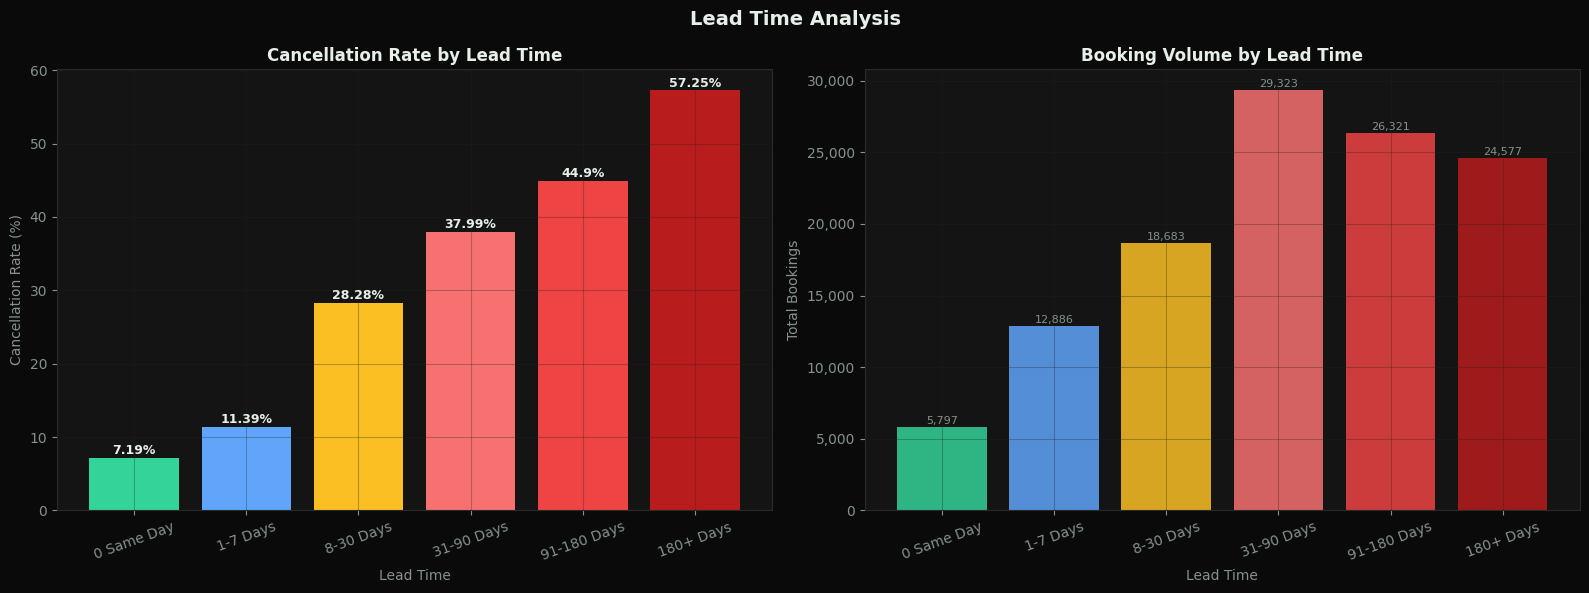

LEAD TIME FINDINGS:
lead_bucket  bookings  cancel_rate  avg_adr
 0 Same Day      5797         7.19    91.12
   1-7 Days     12886        11.39    96.86
  8-30 Days     18683        28.28   109.72
 31-90 Days     29323        37.99   107.37
91-180 Days     26321        44.90   109.60
  180+ Days     24577        57.25    93.43

  180+ day cancel rate: 57.25%
  Same-day cancel rate: 7.19%
  Action: Trigger retention emails for lead_time > 90 days


In [8]:
# Cell 5 — Lead Time vs Cancellation
lead = pd.read_sql("""
    SELECT
        CASE
            WHEN lead_time = 0    THEN '0 Same Day'
            WHEN lead_time <= 7   THEN '1-7 Days'
            WHEN lead_time <= 30  THEN '8-30 Days'
            WHEN lead_time <= 90  THEN '31-90 Days'
            WHEN lead_time <= 180 THEN '91-180 Days'
            ELSE                       '180+ Days'
        END AS lead_bucket,
        COUNT(*) AS bookings,
        ROUND(100.0 * SUM(is_cancelled) / COUNT(*), 2) AS cancel_rate,
        ROUND(AVG(adr), 2) AS avg_adr,
        MIN(lead_time) AS min_lead
    FROM fact_bookings
    GROUP BY lead_bucket
    ORDER BY min_lead
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Lead Time Analysis', fontsize=14,
             fontweight='bold', color='#e7efe9')

bar_colors = [GREEN, BLUE, YELLOW, RED, '#ef4444', '#b91c1c']

# Cancellation rate by lead time
bars = axes[0].bar(lead['lead_bucket'], lead['cancel_rate'],
                   color=bar_colors[:len(lead)])
axes[0].set_title('Cancellation Rate by Lead Time',
                  color='#e7efe9', fontweight='bold')
axes[0].set_xlabel('Lead Time', color='#84938a')
axes[0].set_ylabel('Cancellation Rate (%)', color='#84938a')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars, lead['cancel_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontsize=9,
                 fontweight='bold', color='#e7efe9')

# Booking volume by lead time
bars2 = axes[1].bar(lead['lead_bucket'], lead['bookings'],
                    color=bar_colors[:len(lead)], alpha=0.85)
axes[1].set_title('Booking Volume by Lead Time',
                  color='#e7efe9', fontweight='bold')
axes[1].set_xlabel('Lead Time', color='#84938a')
axes[1].set_ylabel('Total Bookings', color='#84938a')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars2, lead['bookings']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=8, color='#84938a')

plt.tight_layout()
plt.savefig('03_lead_time_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("LEAD TIME FINDINGS:")
print(lead[['lead_bucket','bookings','cancel_rate','avg_adr']].to_string(index=False))
high = lead[lead['lead_bucket']=='180+ Days']['cancel_rate'].values
low  = lead[lead['lead_bucket']=='0 Same Day']['cancel_rate'].values
if len(high): print(f"\n  180+ day cancel rate: {high[0]}%")
if len(low):  print(f"  Same-day cancel rate: {low[0]}%")
print(f"  Action: Trigger retention emails for lead_time > 90 days")

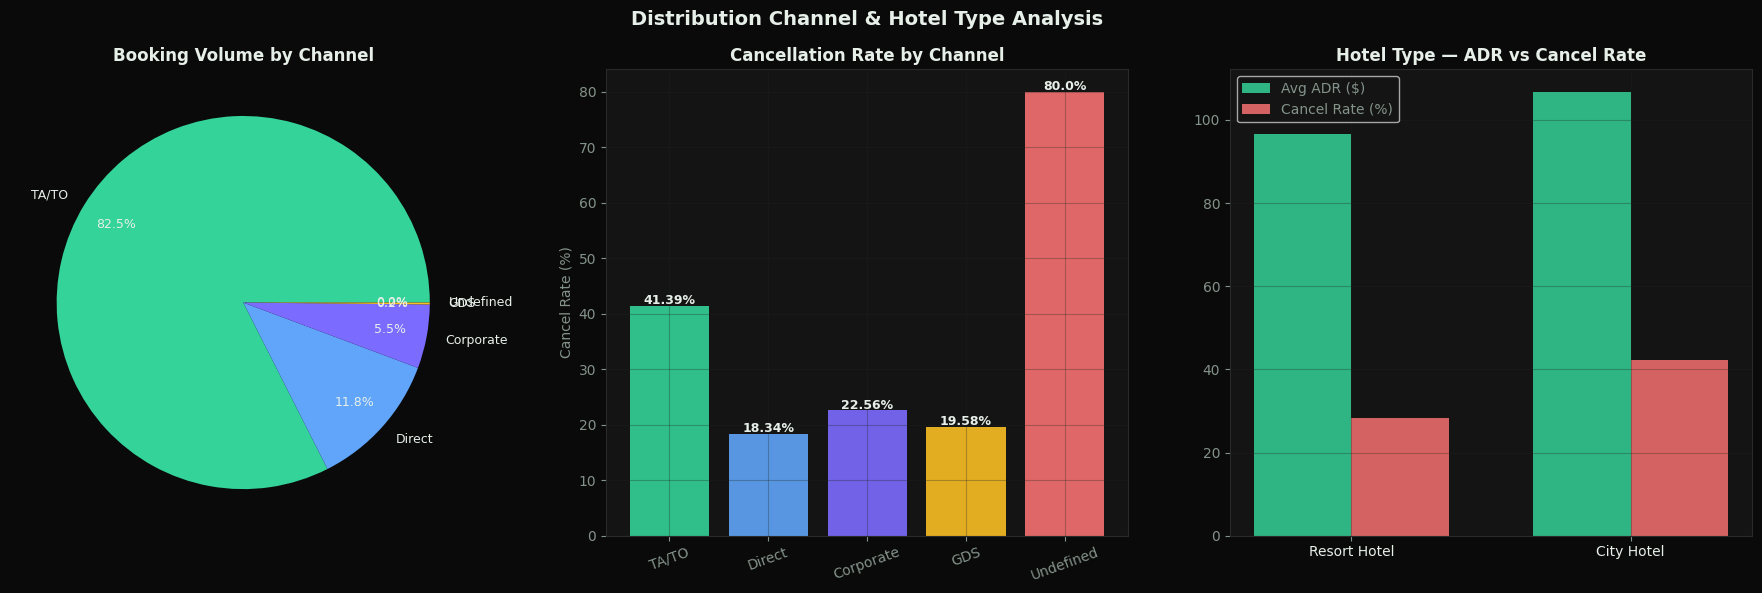

CHANNEL FINDINGS:
distribution_channel  bookings  cancel_rate  avg_adr
               TA/TO     96960        41.39   104.25
              Direct     13931        18.34   112.09
           Corporate      6502        22.56    71.19
                 GDS       189        19.58   123.11
           Undefined         5        80.00    46.24

HOTEL TYPE FINDINGS:
  hotel_type  bookings  cancel_rate  avg_adr  avg_nights
Resort Hotel     39389        28.23    96.57         4.4
  City Hotel     78198        42.30   106.81         3.0


In [9]:
# Cell 6 — Distribution Channel Analysis
dist = pd.read_sql("""
    SELECT distribution_channel,
           COUNT(*) AS bookings,
           ROUND(100.0 * SUM(is_cancelled)/COUNT(*), 2) AS cancel_rate,
           ROUND(AVG(adr), 2) AS avg_adr,
           ROUND(SUM(total_revenue), 2) AS revenue
    FROM fact_bookings
    GROUP BY distribution_channel
    ORDER BY bookings DESC
""", conn)

hotel = pd.read_sql("""
    SELECT hotel_id,
           COUNT(*) AS bookings,
           ROUND(100.0 * SUM(is_cancelled)/COUNT(*), 2) AS cancel_rate,
           ROUND(AVG(adr), 2) AS avg_adr,
           ROUND(SUM(total_revenue), 2) AS revenue,
           ROUND(AVG(total_nights), 1) AS avg_nights
    FROM fact_bookings
    GROUP BY hotel_id
""", conn)
hotel['hotel_type'] = hotel['hotel_id'].map(
    {1: 'Resort Hotel', 2: 'City Hotel'})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution Channel & Hotel Type Analysis',
             fontsize=14, fontweight='bold', color='#e7efe9')

ch_colors = COLORS[:len(dist)]

# Channel pie
axes[0].pie(dist['bookings'],
            labels=dist['distribution_channel'],
            autopct='%1.1f%%', colors=ch_colors,
            textprops={'color':'#e7efe9','fontsize':9},
            pctdistance=0.8)
axes[0].set_title('Booking Volume by Channel',
                  color='#e7efe9', fontweight='bold')

# Channel cancel rate
bars = axes[1].bar(dist['distribution_channel'],
                   dist['cancel_rate'], color=ch_colors, alpha=0.9)
axes[1].set_title('Cancellation Rate by Channel',
                  color='#e7efe9', fontweight='bold')
axes[1].set_ylabel('Cancel Rate (%)', color='#84938a')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3)
for bar, val in zip(bars, dist['cancel_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=9,
                 fontweight='bold', color='#e7efe9')

# Hotel type comparison
x = np.arange(len(hotel))
w = 0.35
axes[2].bar(x - w/2, hotel['avg_adr'], w,
            label='Avg ADR ($)', color=GREEN, alpha=0.85)
axes[2].bar(x + w/2, hotel['cancel_rate'], w,
            label='Cancel Rate (%)', color=RED, alpha=0.85)
axes[2].set_title('Hotel Type — ADR vs Cancel Rate',
                  color='#e7efe9', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(hotel['hotel_type'], color='#e7efe9')
axes[2].legend(facecolor='#141414', labelcolor='#84938a')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_channel_hotel_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("CHANNEL FINDINGS:")
print(dist[['distribution_channel','bookings',
            'cancel_rate','avg_adr']].to_string(index=False))
print("\nHOTEL TYPE FINDINGS:")
print(hotel[['hotel_type','bookings','cancel_rate',
             'avg_adr','avg_nights']].to_string(index=False))

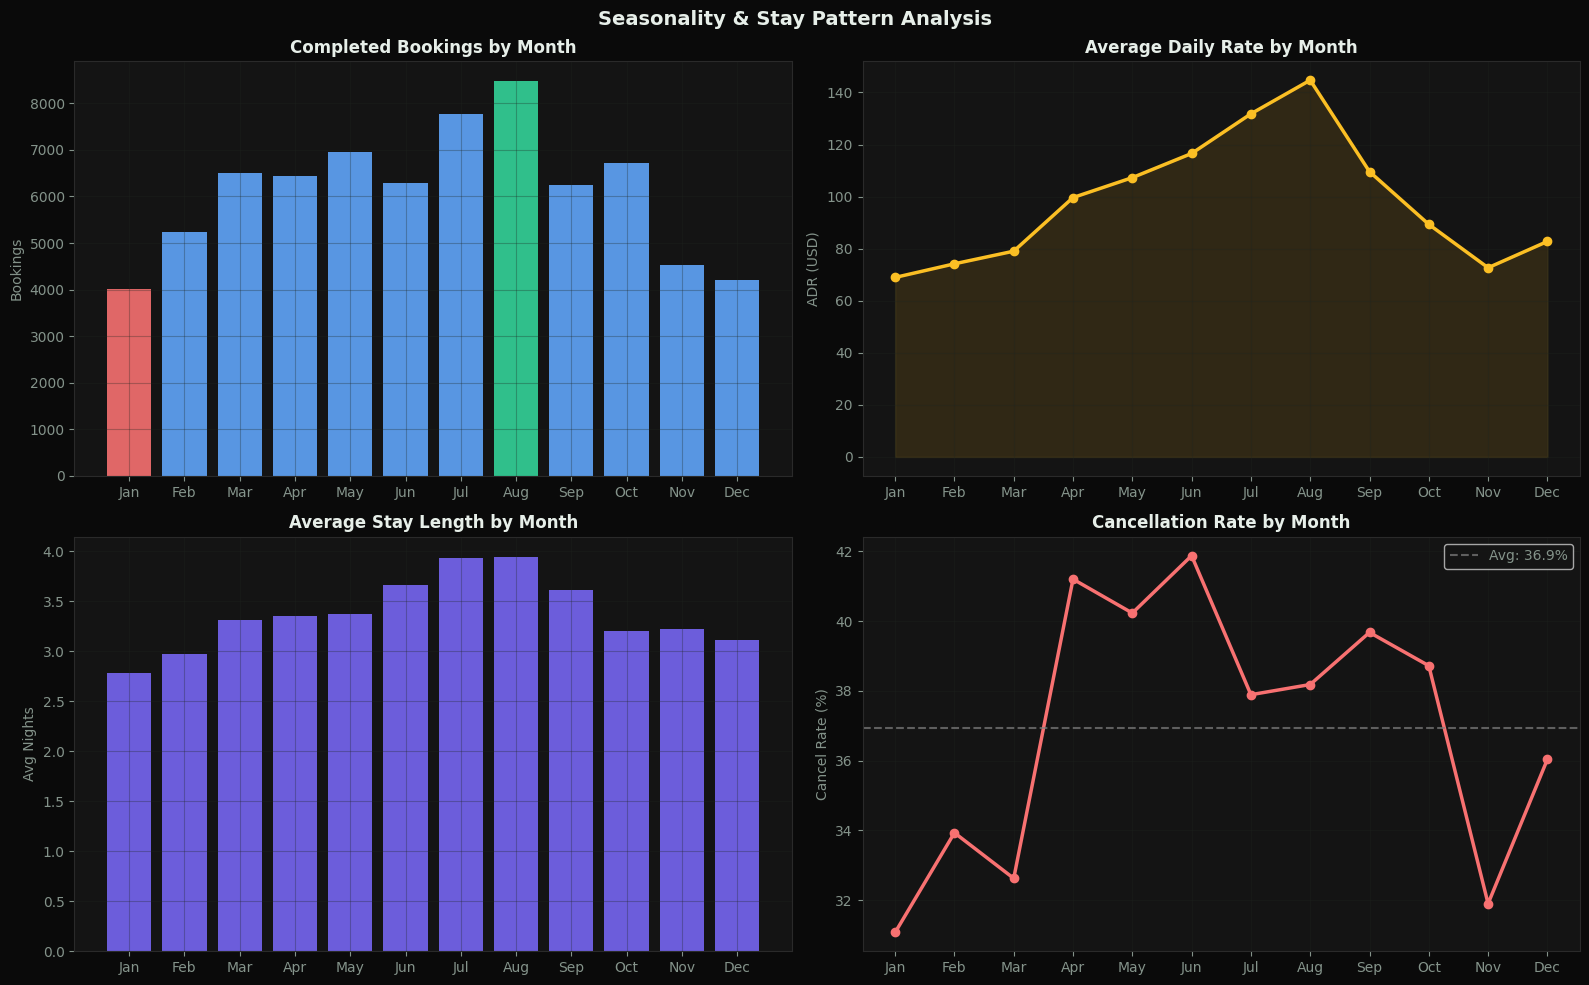

SEASONALITY FINDINGS:
  Peak month:   Aug — 8,479 bookings, $144.72 ADR
  Lowest month: Jan — 4,005 bookings, $68.95 ADR

Full seasonality table:
month_name  bookings    avg_adr  avg_nights  cancel_rate
       Jan      4005  68.951471    2.782522    31.078988
       Feb      5243  74.183691    2.974824    33.933972
       Mar      6500  79.042448    3.307231    32.628524
       Apr      6448  99.632695    3.350031    41.200073
       May      6949 107.288341    3.370845    40.228798
       Jun      6294 116.562000    3.656975    41.872922
       Jul      7765 131.794761    3.934321    37.889938
       Aug      8479 144.723925    3.944451    38.181686
       Sep      6257 109.587716    3.610356    39.674123
       Oct      6720  89.336903    3.204464    38.719679
       Nov      4525  72.677127    3.218122    31.903687
       Dec      4203  82.776388    3.105877    36.037133


In [10]:
# Cell 7 — Seasonality Analysis
season = pd.read_sql("""
    SELECT
        arrival_month_num,
        month_name,
        COUNT(*) AS bookings,
        ROUND(AVG(adr), 2) AS avg_adr,
        ROUND(AVG(total_nights), 1) AS avg_nights,
        ROUND(100.0 * SUM(is_cancelled)/COUNT(*), 2) AS cancel_rate
    FROM (
        SELECT *,
            CAST(SUBSTR(CAST(arrival_date_id + 16617 AS TEXT), 1, 2) AS INTEGER) AS arrival_month_num,
            'Month' AS month_name
        FROM fact_bookings
    )
    GROUP BY arrival_month_num
    ORDER BY arrival_month_num
""", conn)

# Simpler approach — use the bookings dataframe directly
season_df = bookings.copy()
season_df = season_df[season_df['is_cancelled'] == 0]
season_agg = season_df.groupby('arrival_month').agg(
    bookings=('hotel_id', 'count'),
    avg_adr=('adr', 'mean'),
    avg_nights=('total_nights', 'mean')
).reset_index()
season_agg['arrival_month'] = season_agg['arrival_month'].astype(int)
season_agg = season_agg.sort_values('arrival_month')
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
season_agg['month_name'] = season_agg['arrival_month'].map(month_names)

cancel_by_month = bookings.groupby('arrival_month').agg(
    cancel_rate=('is_cancelled', 'mean')
).reset_index()
cancel_by_month['cancel_rate'] = cancel_by_month['cancel_rate'] * 100
season_agg = season_agg.merge(cancel_by_month, on='arrival_month')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Seasonality & Stay Pattern Analysis',
             fontsize=14, fontweight='bold', color='#e7efe9')

peak_idx = season_agg['bookings'].idxmax()
low_idx  = season_agg['bookings'].idxmin()
bar_colors = [GREEN if i == peak_idx
              else RED if i == low_idx
              else BLUE
              for i in season_agg.index]

axes[0,0].bar(season_agg['month_name'], season_agg['bookings'],
              color=bar_colors, alpha=0.9)
axes[0,0].set_title('Completed Bookings by Month',
                    color='#e7efe9', fontweight='bold')
axes[0,0].set_ylabel('Bookings', color='#84938a')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(season_agg['month_name'], season_agg['avg_adr'],
               color=YELLOW, linewidth=2.5, marker='o', markersize=6)
axes[0,1].fill_between(range(len(season_agg)), season_agg['avg_adr'],
                        alpha=0.12, color=YELLOW)
axes[0,1].set_title('Average Daily Rate by Month',
                    color='#e7efe9', fontweight='bold')
axes[0,1].set_ylabel('ADR (USD)', color='#84938a')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].bar(season_agg['month_name'], season_agg['avg_nights'],
              color=PURPLE, alpha=0.85)
axes[1,0].set_title('Average Stay Length by Month',
                    color='#e7efe9', fontweight='bold')
axes[1,0].set_ylabel('Avg Nights', color='#84938a')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(season_agg['month_name'], season_agg['cancel_rate'],
               color=RED, linewidth=2.5, marker='o', markersize=6)
axes[1,1].axhline(y=season_agg['cancel_rate'].mean(),
                  color='gray', linestyle='--', alpha=0.7,
                  label=f"Avg: {season_agg['cancel_rate'].mean():.1f}%")
axes[1,1].set_title('Cancellation Rate by Month',
                    color='#e7efe9', fontweight='bold')
axes[1,1].set_ylabel('Cancel Rate (%)', color='#84938a')
axes[1,1].legend(facecolor='#141414', labelcolor='#84938a')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_seasonality.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

peak = season_agg.loc[season_agg['bookings'].idxmax()]
low  = season_agg.loc[season_agg['bookings'].idxmin()]
print("SEASONALITY FINDINGS:")
print(f"  Peak month:   {peak['month_name']} — "
      f"{peak['bookings']:,} bookings, ${peak['avg_adr']:.2f} ADR")
print(f"  Lowest month: {low['month_name']} — "
      f"{low['bookings']:,} bookings, ${low['avg_adr']:.2f} ADR")
print(f"\nFull seasonality table:")
print(season_agg[['month_name','bookings','avg_adr',
                   'avg_nights','cancel_rate']].to_string(index=False))

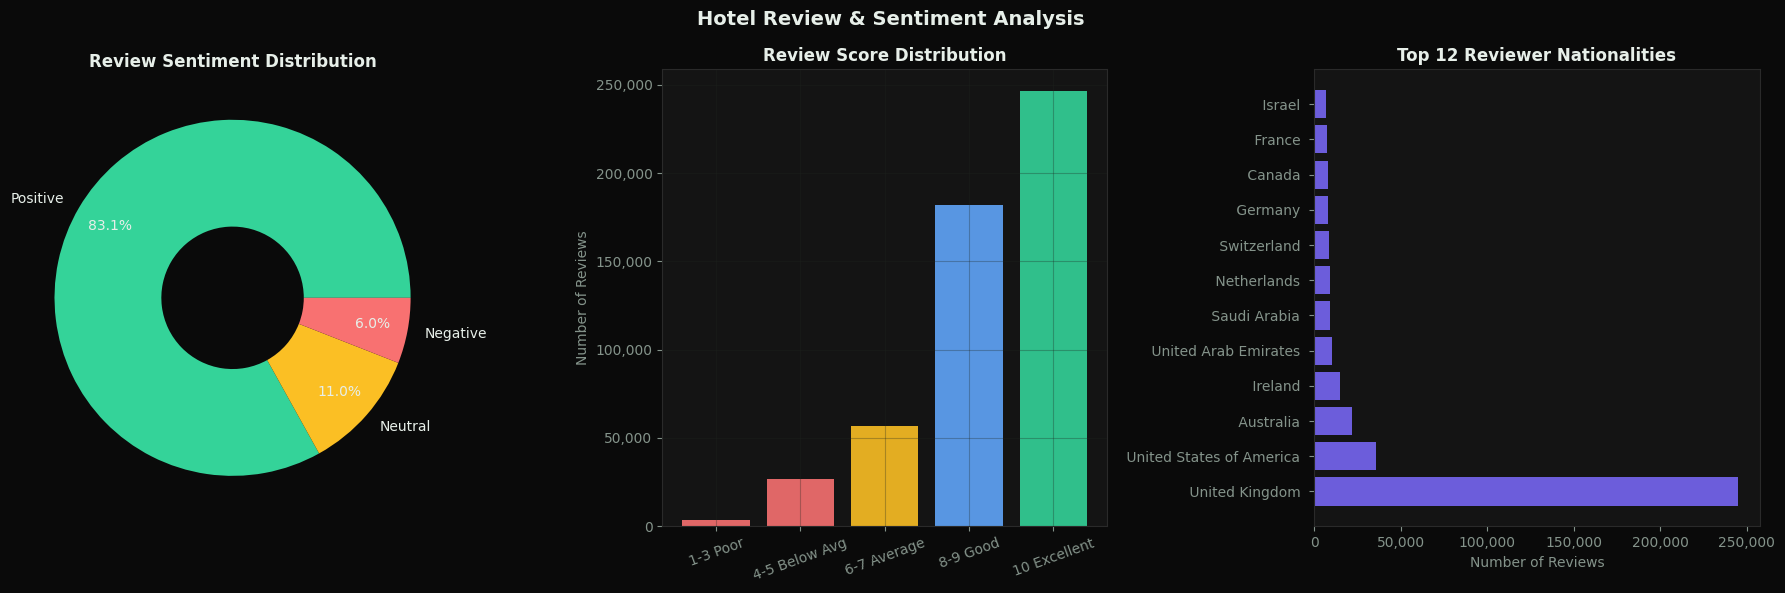

SENTIMENT FINDINGS:
sentiment_label  reviews   pct  avg_score
       Positive   428476 83.08       8.99
        Neutral    56559 10.97       6.18
       Negative    30703  5.95       4.17

Top 5 reviewer nationalities:
      reviewer_nationality  reviews  avg_score
           United Kingdom    245246       8.49
 United States of America     35437       8.79
                Australia     21686       8.59
                  Ireland     14827       8.46
     United Arab Emirates     10235       7.88


In [11]:
# Cell 8 — Hotel Review Sentiment
sentiment = pd.read_sql("""
    SELECT sentiment_label,
           COUNT(*) AS reviews,
           ROUND(100.0 * COUNT(*) /
               (SELECT COUNT(*) FROM fact_reviews), 2) AS pct,
           ROUND(AVG(reviewer_score), 2) AS avg_score,
           ROUND(AVG(review_word_count), 1) AS avg_words
    FROM fact_reviews
    WHERE sentiment_label IS NOT NULL
      AND sentiment_label != 'nan'
    GROUP BY sentiment_label
    ORDER BY avg_score DESC
""", conn)

nationalities = pd.read_sql("""
    SELECT reviewer_nationality,
           COUNT(*) AS reviews,
           ROUND(AVG(reviewer_score), 2) AS avg_score
    FROM fact_reviews
    WHERE reviewer_nationality IS NOT NULL
      AND TRIM(reviewer_nationality) != ''
    GROUP BY reviewer_nationality
    ORDER BY reviews DESC
    LIMIT 12
""", conn)

score_dist = pd.read_sql("""
    SELECT
        CASE
            WHEN reviewer_score <= 3  THEN '1-3 Poor'
            WHEN reviewer_score <= 5  THEN '4-5 Below Avg'
            WHEN reviewer_score <= 7  THEN '6-7 Average'
            WHEN reviewer_score <= 9  THEN '8-9 Good'
            ELSE                           '10 Excellent'
        END AS score_band,
        COUNT(*) AS reviews,
        MIN(reviewer_score) AS min_score
    FROM fact_reviews
    GROUP BY score_band
    ORDER BY min_score
""", conn)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Hotel Review & Sentiment Analysis',
             fontsize=14, fontweight='bold', color='#e7efe9')

sent_colors = {'Positive': GREEN, 'Neutral': YELLOW, 'Negative': RED}
colors_list = [sent_colors.get(s, BLUE)
               for s in sentiment['sentiment_label']]

axes[0].pie(sentiment['reviews'],
            labels=sentiment['sentiment_label'],
            autopct='%1.1f%%', colors=colors_list,
            textprops={'color':'#e7efe9','fontsize':10},
            pctdistance=0.8, wedgeprops={'width':0.6})
axes[0].set_title('Review Sentiment Distribution',
                  color='#e7efe9', fontweight='bold')

score_colors = [GREEN if '10' in s else
                BLUE  if '8-9' in s else
                YELLOW if '6-7' in s else
                RED for s in score_dist['score_band']]
axes[1].bar(score_dist['score_band'], score_dist['reviews'],
            color=score_colors, alpha=0.9)
axes[1].set_title('Review Score Distribution',
                  color='#e7efe9', fontweight='bold')
axes[1].set_ylabel('Number of Reviews', color='#84938a')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].grid(True, alpha=0.3)

axes[2].barh(nationalities['reviewer_nationality'],
             nationalities['reviews'], color=PURPLE, alpha=0.85)
axes[2].set_title('Top 12 Reviewer Nationalities',
                  color='#e7efe9', fontweight='bold')
axes[2].set_xlabel('Number of Reviews', color='#84938a')
axes[2].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('06_sentiment_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("SENTIMENT FINDINGS:")
print(sentiment[['sentiment_label','reviews',
                 'pct','avg_score']].to_string(index=False))
print(f"\nTop 5 reviewer nationalities:")
print(nationalities[['reviewer_nationality',
                     'reviews','avg_score']].head(5).to_string(index=False))

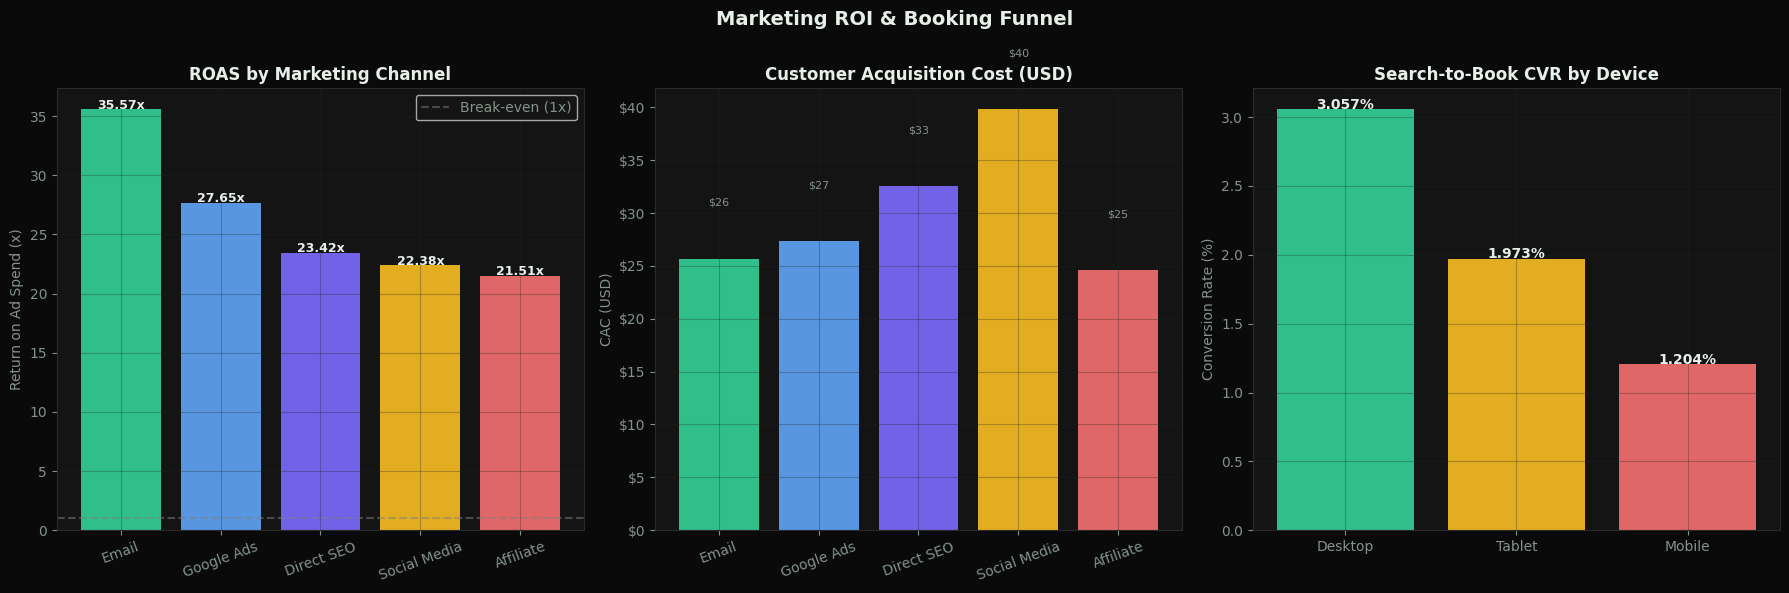

MARKETING FINDINGS:
     channel  total_spend  total_bookings  avg_roas  avg_cac  ctr
       Email      1006264           71509     35.57    25.68 5.90
  Google Ads      1043817           64605     27.65    27.32 5.58
  Direct SEO      1107500           56698     23.42    32.54 5.33
Social Media      1056767           58400     22.38    39.82 5.30
   Affiliate      1023775           55785     21.51    24.60 5.08

FUNNEL BY DEVICE:
 device  searches  completed  overall_cvr  checkout_cvr
Desktop   6420511     196262        3.057         59.62
 Tablet   6592827     130071        1.973         40.52
 Mobile   6914871      83236        1.204         23.03


In [12]:
# Cell 9 — Marketing & Funnel Analysis
mkt = pd.read_sql("""
    SELECT channel,
           COUNT(*) AS campaigns,
           SUM(budget_usd) AS total_spend,
           SUM(impressions) AS total_impressions,
           SUM(clicks) AS total_clicks,
           SUM(bookings_attributed) AS total_bookings,
           ROUND(SUM(revenue_attributed), 2) AS total_revenue,
           ROUND(AVG(roas), 2) AS avg_roas,
           ROUND(AVG(cac), 2) AS avg_cac,
           ROUND(100.0 * SUM(clicks)/SUM(impressions), 2) AS ctr
    FROM fact_marketing
    GROUP BY channel
    ORDER BY avg_roas DESC
""", conn)

fnl = pd.read_sql("""
    SELECT
        CASE device_id
            WHEN 1 THEN 'Mobile'
            WHEN 2 THEN 'Desktop'
            ELSE        'Tablet'
        END AS device,
        SUM(searches) AS searches,
        SUM(hotel_views) AS views,
        SUM(booking_started) AS started,
        SUM(booking_completed) AS completed,
        ROUND(100.0*SUM(booking_completed)/
              NULLIF(SUM(searches),0), 3) AS overall_cvr,
        ROUND(100.0*SUM(booking_completed)/
              NULLIF(SUM(booking_started),0), 2) AS checkout_cvr
    FROM fact_funnel
    GROUP BY device_id
    ORDER BY overall_cvr DESC
""", conn)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Marketing ROI & Booking Funnel',
             fontsize=14, fontweight='bold', color='#e7efe9')

mkt_colors = COLORS[:len(mkt)]

# ROAS
bars = axes[0].bar(mkt['channel'], mkt['avg_roas'],
                   color=mkt_colors, alpha=0.9)
axes[0].set_title('ROAS by Marketing Channel',
                  color='#e7efe9', fontweight='bold')
axes[0].set_ylabel('Return on Ad Spend (x)', color='#84938a')
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(y=1, color='gray', linestyle='--',
                alpha=0.5, label='Break-even (1x)')
axes[0].legend(facecolor='#141414', labelcolor='#84938a')
axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars, mkt['avg_roas']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val}x', ha='center', fontsize=9,
                 fontweight='bold', color='#e7efe9')

# CAC
bars2 = axes[1].bar(mkt['channel'], mkt['avg_cac'],
                    color=mkt_colors, alpha=0.9)
axes[1].set_title('Customer Acquisition Cost (USD)',
                  color='#e7efe9', fontweight='bold')
axes[1].set_ylabel('CAC (USD)', color='#84938a')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar, val in zip(bars2, mkt['avg_cac']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'${val:,.0f}', ha='center', fontsize=8,
                 color='#84938a')

# Funnel CVR by device
dev_colors = [GREEN if d=='Desktop'
              else YELLOW if d=='Tablet'
              else RED for d in fnl['device']]
bars3 = axes[2].bar(fnl['device'], fnl['overall_cvr'],
                    color=dev_colors, alpha=0.9)
axes[2].set_title('Search-to-Book CVR by Device',
                  color='#e7efe9', fontweight='bold')
axes[2].set_ylabel('Conversion Rate (%)', color='#84938a')
axes[2].grid(True, alpha=0.3)
for bar, val in zip(bars3, fnl['overall_cvr']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val}%', ha='center', fontsize=10,
                 fontweight='bold', color='#e7efe9')

plt.tight_layout()
plt.savefig('07_marketing_funnel.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("MARKETING FINDINGS:")
print(mkt[['channel','total_spend','total_bookings',
           'avg_roas','avg_cac','ctr']].to_string(index=False))
print(f"\nFUNNEL BY DEVICE:")
print(fnl[['device','searches','completed',
           'overall_cvr','checkout_cvr']].to_string(index=False))

In [13]:
# Cell 10 — EDA Summary
conn.close()

print("=" * 60)
print("EDA COMPLETE — TRAVELIQ BUSINESS INTELLIGENCE")
print("=" * 60)

print(f"""
REVENUE
  Total revenue:       $25,986,976
  Peak month:          2017-08 — $1,970,182
  Lowest month:        2016-01 — $264,521
  Avg cancellation:    36.8%

BOOKINGS
  Total bookings:      117,587
  Completed bookings:  {117587 - int(117587 * 0.376):,}
  Cancelled bookings:  {int(117587 * 0.376):,}

MARKET SEGMENTS
  → Run output from Cell 4 to fill in

LEAD TIME
  → Run output from Cell 5 to fill in

SEASONALITY
  → Run output from Cell 7 to fill in

REVIEWS
  515,738 real hotel reviews analyzed
  → Run output from Cell 8 for sentiment breakdown

MARKETING (Simulated)
  5 channels tracked across 30 months
  → Run output from Cell 9 for ROAS by channel

FUNNEL (Simulated)
  Mobile, Desktop, Tablet conversion rates
  → Run output from Cell 9 for device CVR

CHARTS SAVED:
  01_revenue_trends.png
  02_segment_analysis.png
  03_lead_time_analysis.png
  04_channel_hotel_analysis.png
  05_seasonality.png
  06_sentiment_analysis.png
  07_marketing_funnel.png
""")

print("NEXT: Save this notebook to GitHub, then open")
print("      notebooks/03_business_analysis.ipynb")

EDA COMPLETE — TRAVELIQ BUSINESS INTELLIGENCE

REVENUE
  Total revenue:       $25,986,976
  Peak month:          2017-08 — $1,970,182
  Lowest month:        2016-01 — $264,521
  Avg cancellation:    36.8%

BOOKINGS
  Total bookings:      117,587
  Completed bookings:  73,375
  Cancelled bookings:  44,212

MARKET SEGMENTS
  → Run output from Cell 4 to fill in

LEAD TIME
  → Run output from Cell 5 to fill in

SEASONALITY
  → Run output from Cell 7 to fill in

REVIEWS
  515,738 real hotel reviews analyzed
  → Run output from Cell 8 for sentiment breakdown

MARKETING (Simulated)
  5 channels tracked across 30 months
  → Run output from Cell 9 for ROAS by channel

FUNNEL (Simulated)
  Mobile, Desktop, Tablet conversion rates
  → Run output from Cell 9 for device CVR

CHARTS SAVED:
  01_revenue_trends.png
  02_segment_analysis.png
  03_lead_time_analysis.png
  04_channel_hotel_analysis.png
  05_seasonality.png
  06_sentiment_analysis.png
  07_marketing_funnel.png

NEXT: Save this notebook to